In [ ]:
## Importing libaries
## tensor flow keras  is used for the classiucal decoder for the this particular project
### numpy obsviously is used , mainly for the dimensionality of the storing array
#### pennylane for the Quantumn machine learnning , device and other parametres
##### quimb.tensor is mainly used for the importing the tensor network librarry and using tensor trains and mps and peps
##### CV2 is our open cv library usually used for collor encoding image to array conversion and flatteing
###### Qiskit our main simulator of the qbits and and importinf for the gates for amplitiude encoding
import tensorflow.keras
import numpy as pop
import cv2
import pennylane as qml
from pennylane import numpy as np
from qiskit import QuantumCircuit , transpile
from qiskit_aer import AerSimulator
import quimb.tensor as qtn
from tensorflow.keras import models , layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout

2026-03-03 13:33:00.423764: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-03 13:33:01.945645: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 13:33:06.869303: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


##### IMAGE Preprocessing

In [ ]:
##### IMAGE PREPERATION USING OPEN CV
## FIRST IMPORT the image and put it into a parametre

image = cv2.imread("/home/adminpc/Documents/Professors_Diary/QuantumnComputing/qenv/Qunatumcomputingalgos/Quantumn_image_reconstruction/Images_for_classification/monalisa.jpg")
image = cv2.cvtColor(image , cv2.COLOR_BGR2GRAY) ### changes the colored monalisa photo to black and white photo and stores the respectve data ouput
size = 256
## now we wil rescale the image to 256 - 256 image
image = cv2.resize(image , (size , size))
image_data=[]
image_data.append(pop.array(image))
#print(image_data) ## Coverted the nested array to a nump array and the fed into a list
img_array = pop.reshape(image_data , (len(image_data) , size , size , 1))## reshapped the image_data to which is a 256*256 matrix to a 1 , 256 , 256 ,1 array
#print(img_array.shape)
img_array = img_array.astype('float32') ## changes the image arry values to float 32
img_array /= 255.0
img_array_flat = img_array.flatten()
print("The flatten image array in float 32 form is " , img_array_flat , img_array_flat.size, img_array_flat.shape);

## this img_array_flat is esssential the preprocessed image array that will enter into the mps compressor

The flatten image array in float 32 form is  [0.4117647  0.3019608  0.41568628 ... 0.03137255 0.07058824 0.26666668] 65536 (65536,)


##### MPS COMPRESSION AND RENORMALIZATION BEFORE AMPLITUDE ENCODING

In [ ]:
## This img_data_flat is a float32 array witha size of 65536 and a shape of 65536 a single dimensional array containing 65536

img_array_flat = pop.asarray(img_array_flat).ravel()
img_array_flat = img_array_flat / pop.linalg.norm(img_array_flat) ### This is the linearly normalized data float32 matrix
#print(img_array_flat)
dimensions = [2]*16
mps = qtn.MatrixProductState.from_dense(img_array_flat , dims = dimensions)## encoding the the img_array_flat to mps_tensor
#print(mps)
mps.compress(max_bond = 64 , cutoff = 1e-8 )
#print(mps)

img_data_flat_mps_compressed = pop.asarray(mps.to_dense()).ravel()
img_data_flat_mps_compressed= img_data_flat_mps_compressed/(np.linalg.norm(img_data_flat_mps_compressed)+ 1e-12)
#print(img_data_flat_mps_compressed)
img_array_reconstructed = pop.asarray(mps.to_dense()).ravel()
error_while_reconstruction = (np.linalg.norm(img_data_flat_mps_compressed-img_array_reconstructed)/np.linalg.norm(img_data_flat_mps_compressed))
print("The relative reconstruction error fidelity is " , error_while_reconstruction*100,"%")




The relative reconstruction error fidelity is  0.20473604 %


#### PROCESSING OF DATA
##### Quantumn Amplitude Encoding using mps compressed image data

In [ ]:
import pennylane as qml
from pennylane import numpy as np

n_qubits = 16
n_layers = 4

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qae(weights, amplitudes):
    qml.AmplitudeEmbedding(amplitudes, wires=range(n_qubits), normalize=True)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

amplitudes = np.array(img_data_flat_mps_compressed, requires_grad=False)

def cost_fn(weights):
    output = qae(weights, amplitudes)
    amp_target = amplitudes[:n_qubits]
    amp_loss = np.mean((np.array(output) - amp_target) ** 2)
    weight_loss = np.mean(weights ** 2)
    return amp_loss + 1e-3 * weight_loss

weights = 0.01 * np.random.randn(n_layers, n_qubits, 3, requires_grad=True)
optimizer = qml.AdamOptimizer(0.02)

for step in range(200):
    weights = optimizer.step(cost_fn, weights)
    if step % 20 == 0:
        print("Step", step, "Cost", cost_fn(weights))

print("Optimized weights:", weights)
latent = np.array(qae(weights, amplitudes), dtype=np.float32).reshape(1, n_qubits)
print("Latent shape:", latent.shape)


Step 0 Cost 1.8492309317126666e-05
Step 20 Cost 8.132180804570595e-06
Step 40 Cost 6.938467145611027e-06
Step 60 Cost 6.31182250697806e-06
Step 80 Cost 6.168931849819253e-06
Step 100 Cost 6.1488155048251674e-06
Step 120 Cost 6.122169930926367e-06
Step 140 Cost 6.045263267891237e-06
Step 160 Cost 6.034469112967705e-06
Step 180 Cost 6.034095426358047e-06
Optimized weights: [[[ 9.74748442e-08 -1.16605584e-02 -5.02254442e-08]
  [-7.29176494e-08  1.10372220e-01  1.74912886e-07]
  [-1.12227426e-08  2.71745655e-03 -1.86818802e-07]
  [-2.59444958e-08 -2.47808490e-02  7.80735509e-08]
  [ 1.23137473e-07 -2.06832813e-01 -9.20063973e-08]
  [ 1.26346847e-07  3.09578178e-02 -4.44577308e-08]
  [-2.86818777e-07 -3.78363586e-02  5.26099255e-07]
  [ 9.56535455e-08  1.36525614e-01 -1.06942788e-07]
  [-1.58674671e-07 -1.68675823e-01 -3.28402894e-07]
  [-6.55137779e-08  1.33866574e-01 -1.10743398e-07]
  [ 1.84490657e-07 -1.23039839e-01 -2.32628782e-07]
  [-1.98377473e-08 -6.00285650e-02  3.50388024e-07]
  

##### DECODING OF PROCESSED DATA

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - loss: 0.0808 - mae: 0.2435 - val_loss: 0.0808 - val_mae: 0.2434


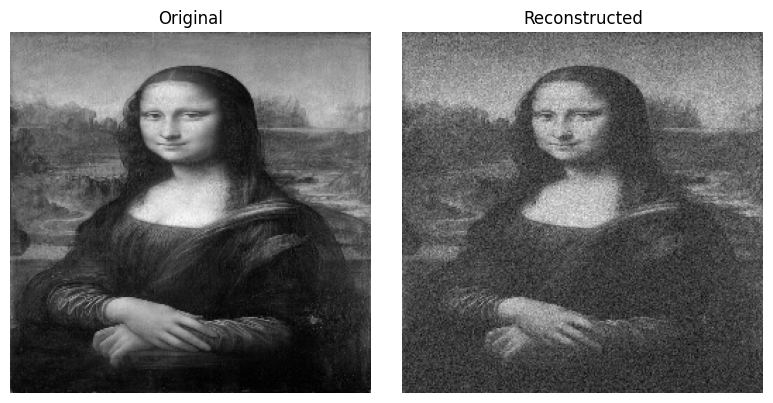

Decoder reconstruction MSE: 0.08078093826770782


In [ ]:
# Classical decoder and reconstruction
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

decoder = models.Sequential([
    layers.Input(shape=(n_qubits,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(2048, activation="relu"),
    layers.Dense(size * size, activation="sigmoid"),
    layers.Reshape((size, size, 1)),
])

decoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

target = image.reshape(1, size, size, 1).astype("float32") / 255.0
history = decoder.fit(latent, target, epochs=1, verbose=1, validation_data=(latent, target))
pred = decoder.predict(latent, verbose=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(target[0, :, :, 0], cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed")
plt.imshow(pred[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

recon_mse = float(np.mean((target - pred) ** 2))
print("Decoder reconstruction MSE:", recon_mse)




Relative reconstruction error: 0.0640057425
State fidelity:               0.9959074607


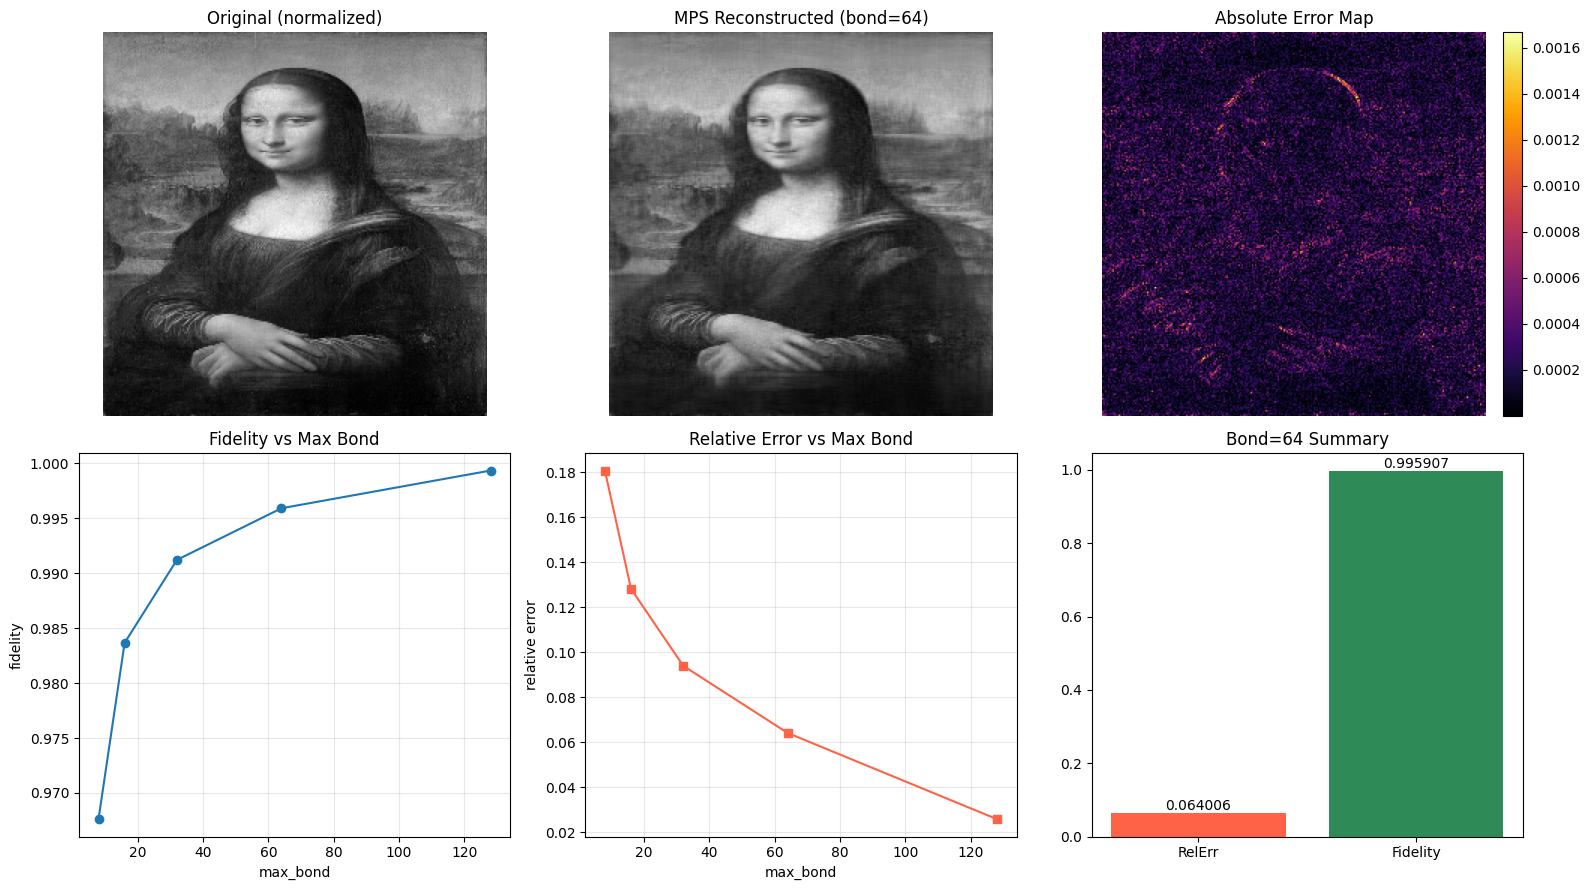

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
x_true = np.asarray(img_array_flat).ravel().astype(np.float64)
x_true = x_true / (np.linalg.norm(x_true) + 1e-12)

n_qubits = 16
dims = [2] * n_qubits

if x_true.size != 2**n_qubits:
    raise ValueError(f"x_true size = {x_true.size}, expected {2**n_qubits} for {n_qubits} qubits.")

def mps_reconstruct_metrics(x, max_bond=64, cutoff=1e-8):
    mps = qtn.MatrixProductState.from_dense(x, dims=dims)
    mps.compress(max_bond=max_bond, cutoff=cutoff)

    x_rec = np.asarray(mps.to_dense()).ravel().astype(np.float64)
    x_rec = x_rec / (np.linalg.norm(x_rec) + 1e-12)

    rel_err = np.linalg.norm(x - x_rec) / (np.linalg.norm(x) + 1e-12)
    fidelity = np.abs(np.vdot(x, x_rec))**2
    return x_rec, float(rel_err), float(fidelity)

x_rec, rel_err, fidelity = mps_reconstruct_metrics(x_true, max_bond=64, cutoff=1e-8)

print(f"Relative reconstruction error: {rel_err:.10f}")
print(f"State fidelity:               {fidelity:.10f}")

bond_dims = [8, 16, 32, 64, 128]
errs, fids = [], []

for b in bond_dims:
    _, e, f = mps_reconstruct_metrics(x_true, max_bond=b, cutoff=1e-8)
    errs.append(e)
    fids.append(f)


n = int(np.sqrt(x_true.size))  # 256 for 16 qubits
img_true = x_true.reshape(n, n)
img_rec  = x_rec.reshape(n, n)
err_map  = np.abs(img_true - img_rec)


fig, ax = plt.subplots(2, 3, figsize=(16, 9))

ax[0, 0].imshow(img_true, cmap="gray")
ax[0, 0].set_title("Original (normalized)")
ax[0, 0].axis("off")

ax[0, 1].imshow(img_rec, cmap="gray")
ax[0, 1].set_title("MPS Reconstructed (bond=64)")
ax[0, 1].axis("off")

im = ax[0, 2].imshow(err_map, cmap="inferno")
ax[0, 2].set_title("Absolute Error Map")
ax[0, 2].axis("off")
plt.colorbar(im, ax=ax[0, 2], fraction=0.046, pad=0.04)

ax[1, 0].plot(bond_dims, fids, marker="o")
ax[1, 0].set_title("Fidelity vs Max Bond")
ax[1, 0].set_xlabel("max_bond")
ax[1, 0].set_ylabel("fidelity")
ax[1, 0].grid(alpha=0.3)

ax[1, 1].plot(bond_dims, errs, marker="s", color="tomato")
ax[1, 1].set_title("Relative Error vs Max Bond")
ax[1, 1].set_xlabel("max_bond")
ax[1, 1].set_ylabel("relative error")
ax[1, 1].grid(alpha=0.3)

metric_names = ["RelErr", "Fidelity"]
metric_vals = [rel_err, fidelity]
bars = ax[1, 2].bar(metric_names, metric_vals, color=["tomato", "seagreen"])
ax[1, 2].set_title("Bond=64 Summary")
for b, v in zip(bars, metric_vals):
    ax[1, 2].text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.6f}",
                  ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


## EXTRA PARTS

In [ ]:
!pip install scikit-image


MSE  : 0.08078094
MAE  : 0.24339020
PSNR : 10.927 dB
SSIM : 0.27827

Decoder input test (lower is better):
MSE(true latent)   : 0.08078093826770782
MSE(shuffled latent): 0.08078093826770782
MSE(zero latent)   : 0.08078118413686752
MSE(random latent) : 0.08080616593360901


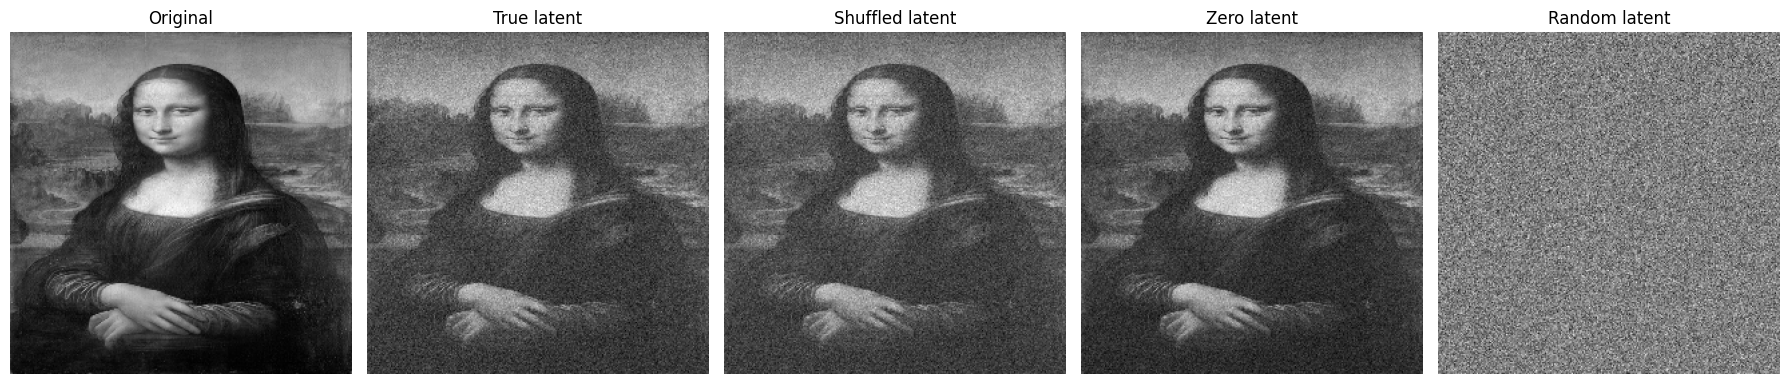

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# -----------------------------
# 1) Quality metrics
# -----------------------------
y_true = target[0, :, :, 0]
y_pred = pred[0, :, :, 0]

mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
psnr = peak_signal_noise_ratio(y_true, y_pred, data_range=1.0)
ssim = structural_similarity(y_true, y_pred, data_range=1.0)

print(f"MSE  : {mse:.8f}")
print(f"MAE  : {mae:.8f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {ssim:.5f}")

# -----------------------------
# 2) Latent dependence test
# -----------------------------
z_true = latent.copy()
z_zero = np.zeros_like(latent)
z_rand = np.random.randn(*latent.shape).astype(np.float32)
z_shuffle = latent[:, np.random.permutation(latent.shape[1])]

pred_true = decoder.predict(z_true, verbose=0)
pred_zero = decoder.predict(z_zero, verbose=0)
pred_rand = decoder.predict(z_rand, verbose=0)
pred_shuffle = decoder.predict(z_shuffle, verbose=0)

def img_mse(x): return np.mean((target - x) ** 2)

print("\nDecoder input test (lower is better):")
print("MSE(true latent)   :", float(img_mse(pred_true)))
print("MSE(shuffled latent):", float(img_mse(pred_shuffle)))
print("MSE(zero latent)   :", float(img_mse(pred_zero)))
print("MSE(random latent) :", float(img_mse(pred_rand)))

# -----------------------------
# 3) PPT figure (easy to show)
# -----------------------------
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
ax[0].imshow(y_true, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(pred_true[0,:,:,0], cmap="gray"); ax[1].set_title("True latent"); ax[1].axis("off")
ax[2].imshow(pred_shuffle[0,:,:,0], cmap="gray"); ax[2].set_title("Shuffled latent"); ax[2].axis("off")
ax[3].imshow(pred_zero[0,:,:,0], cmap="gray"); ax[3].set_title("Zero latent"); ax[3].axis("off")
ax[4].imshow(pred_rand[0,:,:,0], cmap="gray"); ax[4].set_title("Random latent"); ax[4].axis("off")
plt.tight_layout()
plt.show()


Dataset shape: (12, 256, 256)
Amplitude dataset: (12, 65536)
Mean MPS relative error: 0.0603009424481949
Step 0 Cost 0.15147487264425805
Step 20 Cost 0.003653946398333861
Step 40 Cost 0.000250983003047092
Step 60 Cost 4.718329187583902e-05
Step 80 Cost 8.766286636064866e-06
Step 100 Cost 4.883697082212658e-06
Step 120 Cost 4.395619054881323e-06
Step 140 Cost 4.294070584690716e-06
Step 160 Cost 4.270766635721977e-06
Step 180 Cost 4.259206550780372e-06
Final encoder cost: 4.2489113274537464e-06
X_latent: (12, 16) Y_img: (12, 256, 256, 1)
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.0823 - mae: 0.2463WARNING:tensorflow:5 out of the last 15 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x76fff04234c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of ten

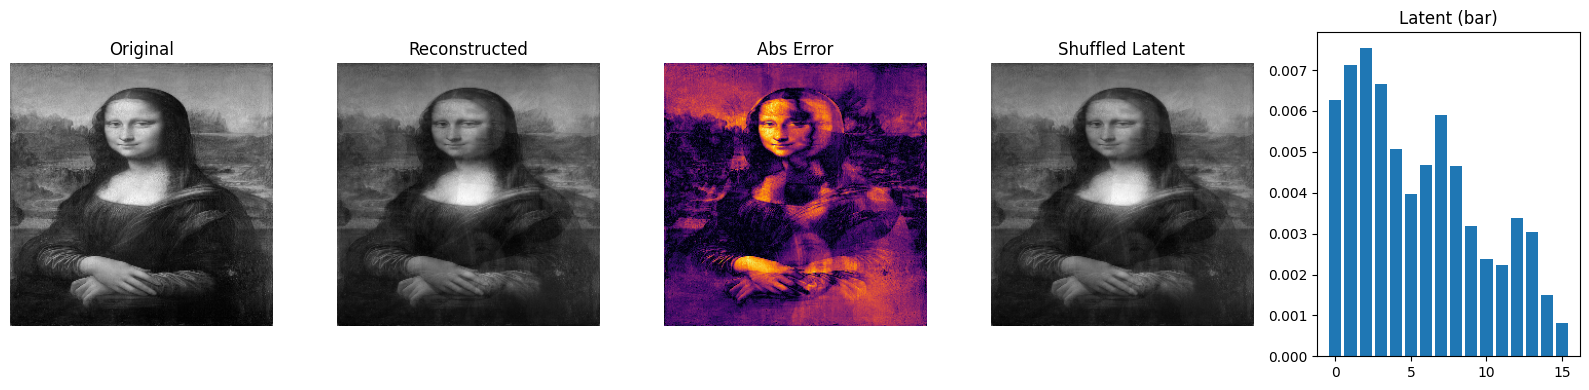

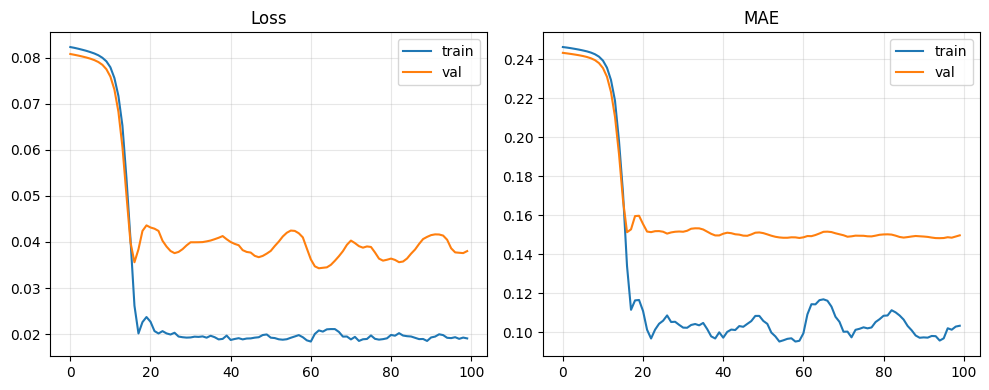

In [ ]:
# Full pipeline: MPS compression + quantum encoder + decoder + quality checks

import cv2
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import pennylane as qml
from pennylane import numpy as pnp
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# 1) Image preprocessing + augmentations
# -----------------------------
IMAGE_PATH = "/home/adminpc/Documents/Professors_Diary/QuantumnComputing/qenv/Qunatumcomputingalgos/Quantumn_image_reconstruction/Images_for_classification/monalisa.jpg"
SIZE = 256
n_qubits = 16
n_layers = 4

image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
image = cv2.resize(image, (SIZE, SIZE)).astype(np.float32) / 255.0

def make_augmented_images(img):
    imgs = [img]
    imgs.append(cv2.flip(img, 1))
    imgs.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    imgs.append(cv2.rotate(img, cv2.ROTATE_180))
    imgs.append(np.clip(img * 0.85, 0.0, 1.0))
    imgs.append(np.clip(img * 1.15, 0.0, 1.0))
    imgs.append(np.clip(img + 0.08, 0.0, 1.0))
    imgs.append(np.clip(img - 0.08, 0.0, 1.0))
    imgs.append(cv2.GaussianBlur(img, (5, 5), 0))
    noise = np.random.normal(0, 0.01, img.shape).astype(np.float32)
    imgs.append(np.clip(img + noise, 0.0, 1.0))
    imgs.append(cv2.flip(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE), 1))
    imgs.append(cv2.flip(cv2.rotate(img, cv2.ROTATE_180), 1))
    return np.array(imgs, dtype=np.float32)

images = make_augmented_images(image)
print("Dataset shape:", images.shape)  # (N, 256, 256)

# -----------------------------
# 2) MPS compression -> amplitude vectors
# -----------------------------
state_dim = 2 ** n_qubits
if SIZE * SIZE != state_dim:
    raise ValueError(f"For {n_qubits} qubits, image size must be {state_dim} pixels")

def mps_compress_to_amplitudes(gray_img, max_bond=64, cutoff=1e-8):
    x = np.asarray(gray_img, dtype=np.float64).reshape(-1)
    x = x / (np.linalg.norm(x) + 1e-12)

    mps = qtn.MatrixProductState.from_dense(x, dims=[2] * n_qubits)
    mps.compress(max_bond=max_bond, cutoff=cutoff)

    amp = np.asarray(mps.to_dense()).reshape(-1)
    amp = amp / (np.linalg.norm(amp) + 1e-12)

    rel_err = np.linalg.norm(x - amp) / (np.linalg.norm(x) + 1e-12)
    return amp.astype(np.float64), float(rel_err)

amplitudes_list, mps_errors = [], []
for img in images:
    amp, err = mps_compress_to_amplitudes(img)
    amplitudes_list.append(amp)
    mps_errors.append(err)

amplitudes_ds = np.array(amplitudes_list, dtype=np.float64)
print("Amplitude dataset:", amplitudes_ds.shape)
print("Mean MPS relative error:", float(np.mean(mps_errors)))

# -----------------------------
# 3) Quantum encoder
# -----------------------------
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qae(weights, amplitudes):
    qml.AmplitudeEmbedding(amplitudes, wires=range(n_qubits), normalize=True)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def make_pooled_target(amplitudes):
    x = pnp.array(amplitudes, requires_grad=False)
    x = x.reshape(n_qubits, -1)                 # 65536 -> 16 groups
    t = pnp.mean(x, axis=1)                     # pooled target (16 values)
    t = t / (pnp.linalg.norm(t) + 1e-12)
    return t

train_amplitudes = pnp.array(amplitudes_ds[0], requires_grad=False)
pooled_target = make_pooled_target(train_amplitudes)

def cost_fn(weights):
    out = pnp.array(qae(weights, train_amplitudes))
    out = out / (pnp.linalg.norm(out) + 1e-12)
    amp_loss = pnp.mean((out - pooled_target) ** 2)
    weight_loss = pnp.mean(weights ** 2)
    return amp_loss + 1e-4 * weight_loss

weights = 0.01 * pnp.random.randn(n_layers, n_qubits, 3, requires_grad=True)
optimizer = qml.AdamOptimizer(0.02)

for step in range(200):
    weights = optimizer.step(cost_fn, weights)
    if step % 20 == 0:
        print("Step", step, "Cost", float(cost_fn(weights)))

print("Final encoder cost:", float(cost_fn(weights)))

# Build latent dataset
latents = []
for amp in amplitudes_ds:
    amp_p = pnp.array(amp, requires_grad=False)
    z = np.array(qae(weights, amp_p), dtype=np.float32)
    latents.append(z)

X_latent = np.array(latents, dtype=np.float32)        # (N, 16)
Y_img = images[..., None].astype(np.float32)          # (N, 256, 256, 1)
print("X_latent:", X_latent.shape, "Y_img:", Y_img.shape)

# -----------------------------
# 4) Decoder training
# -----------------------------
decoder = models.Sequential([
    layers.Input(shape=(n_qubits,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(256, activation="relu"),
    layers.Dense(1024, activation="relu"),
    layers.Dense(SIZE * SIZE, activation="sigmoid"),
    layers.Reshape((SIZE, SIZE, 1)),
])

decoder.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = decoder.fit(
    X_latent, Y_img,
    epochs=100,
    batch_size=4,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

# -----------------------------
# 5) Metrics + latent dependence test
# -----------------------------
pred_true = decoder.predict(X_latent, verbose=0)

perm = np.random.permutation(len(X_latent))
pred_shuffle = decoder.predict(X_latent[perm], verbose=0)
pred_zero = decoder.predict(np.zeros_like(X_latent), verbose=0)
pred_rand = decoder.predict(np.random.randn(*X_latent.shape).astype(np.float32), verbose=0)

mse_true = float(np.mean((pred_true - Y_img) ** 2))
mae_true = float(np.mean(np.abs(pred_true - Y_img)))
mse_shuffle = float(np.mean((pred_shuffle - Y_img) ** 2))
mse_zero = float(np.mean((pred_zero - Y_img) ** 2))
mse_rand = float(np.mean((pred_rand - Y_img) ** 2))

psnr = float(tf.reduce_mean(tf.image.psnr(Y_img, pred_true, max_val=1.0)).numpy())
ssim = float(tf.reduce_mean(tf.image.ssim(Y_img, pred_true, max_val=1.0)).numpy())

print("\n=== Reconstruction Metrics ===")
print(f"MSE  : {mse_true:.8f}")
print(f"MAE  : {mae_true:.8f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {ssim:.5f}")

print("\n=== Decoder Input Test (lower is better) ===")
print("MSE(true latent)    :", mse_true)
print("MSE(shuffled latent):", mse_shuffle)
print("MSE(zero latent)    :", mse_zero)
print("MSE(random latent)  :", mse_rand)
print("Latent gap (shuffle - true):", mse_shuffle - mse_true)

# -----------------------------
# 6) PPT-ready plots
# -----------------------------
idx = 0
orig = Y_img[idx, :, :, 0]
reco = pred_true[idx, :, :, 0]
shuf = pred_shuffle[idx, :, :, 0]
err = np.abs(orig - reco)

plt.figure(figsize=(16, 4))
plt.subplot(1, 5, 1); plt.title("Original"); plt.imshow(orig, cmap="gray"); plt.axis("off")
plt.subplot(1, 5, 2); plt.title("Reconstructed"); plt.imshow(reco, cmap="gray"); plt.axis("off")
plt.subplot(1, 5, 3); plt.title("Abs Error"); plt.imshow(err, cmap="inferno"); plt.axis("off")
plt.subplot(1, 5, 4); plt.title("Shuffled Latent"); plt.imshow(shuf, cmap="gray"); plt.axis("off")
plt.subplot(1, 5, 5); plt.title("Latent (bar)"); plt.bar(np.arange(n_qubits), X_latent[idx])
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE"); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
import pennylane as qml
from tensorflow.keras import models, layers

############################################
# 1 LOAD MONA LISA
############################################

image_path = "/monalisa.jpg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

size = 256
img = cv2.resize(img,(size,size))

############################################
# 2 DATA AUGMENTATION
############################################

dataset = []

for i in range(200):

    angle = np.random.uniform(-15,15)

    M = cv2.getRotationMatrix2D((size/2,size/2),angle,1)

    rotated = cv2.warpAffine(img,M,(size,size))

    noise = np.random.normal(0,5,(size,size))

    augmented = rotated + noise

    augmented = np.clip(augmented,0,255)

    dataset.append(augmented)

dataset = np.array(dataset).astype("float32")/255.0

print("Dataset shape:",dataset.shape)

############################################
# 3 FLATTEN
############################################

dataset_flat = dataset.reshape(len(dataset),-1)

dataset_flat = dataset_flat / np.linalg.norm(dataset_flat,axis=1,keepdims=True)

############################################
# 4 MPS COMPRESSION (FIXED)
############################################

dims = [2]*16

mps_dataset = []

for vec in dataset_flat:

    vec = vec.flatten()
    vec = vec / np.linalg.norm(vec)

    mps = qtn.MatrixProductState.from_dense(vec,dims=dims)

    mps.compress(max_bond=64,cutoff=1e-8)

    compressed = mps.to_dense()

    compressed = np.array(compressed).flatten()

    compressed = compressed / np.linalg.norm(compressed)

    mps_dataset.append(compressed)

mps_dataset = np.array(mps_dataset)

print("Compressed dataset shape:",mps_dataset.shape)

############################################
# 5 QUANTUM ENCODER
############################################

n_qubits = 16
n_layers = 4

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)

def qae(weights, amplitudes):

    qml.AmplitudeEmbedding(
        amplitudes,
        wires=range(n_qubits),
        normalize=True
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(n_qubits)
    )

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

############################################
# 6 LATENT GENERATION
############################################

weights = 0.01*np.random.randn(n_layers,n_qubits,3)

latent_dataset = []

for vec in mps_dataset:

    latent = qae(weights,vec)

    latent_dataset.append(latent)

latent_dataset = np.array(latent_dataset)

print("Latent shape:",latent_dataset.shape)

############################################
# 7 DECODER
############################################

decoder = models.Sequential([

    layers.Input(shape=(n_qubits,)),

    layers.Dense(64,activation="relu"),
    layers.Dense(256,activation="relu"),

    layers.Dense(4096,activation="relu"),

    layers.Reshape((64,64,1)),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(16,3,padding="same",activation="relu"),

    layers.UpSampling2D((2,2)),
    layers.Conv2D(1,3,padding="same",activation="sigmoid")

])

decoder.compile(
    optimizer="adam",
    loss="mse"
)

############################################
# 8 TRAIN
############################################

decoder.fit(
    latent_dataset,
    dataset.reshape(len(dataset),256,256,1),
    epochs=20,
    batch_size=16
)

############################################
# 9 TEST
############################################

pred = decoder.predict(latent_dataset[:5])

for i in range(5):

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(dataset[i],cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(pred[i].reshape(256,256),cmap="gray")
    plt.axis("off")

    plt.show()

############################################
# 10 MSE
############################################

mse = np.mean((dataset[:5] - pred.reshape(5,256,256))**2)

print("Reconstruction MSE:",mse)